In [ ]:
%pip install --upgrade --user \
    Pillow \
    google-adk==1.36.1 \
    google-genai==2.11.0 \
    google-cloud-aiplatform==1.160.0

In [11]:
import IPython
app = IPython.Application.instance()
_ = app.kernel.do_shutdown(True)

## 初期設定

In [1]:
# Standard library
import asyncio
import base64
import io
import json
import os
import re
import urllib
import uuid
from google import auth
from pydantic import BaseModel, Field

# Third-party libraries
from IPython.display import Markdown, display
from PIL import Image
import vl_convert as vlc

# Google Cloud & Vertex AI
import vertexai
from google.genai import Client
from google.genai.types import GenerateContentConfig, Part
from vertexai.agent_engines import AdkApp

# Google ADK
from google.adk.agents.llm_agent import LlmAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.tools import ToolContext
from google.adk.tools import google_search
from google.adk.tools.agent_tool import AgentTool

# Initialize Vertex AI
[PROJECT_ID] = !gcloud config list --format 'value(core.project)' 2>/dev/null
LOCATION = 'us-central1'
vertexai.init(project=PROJECT_ID, location=LOCATION)

os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
os.environ['GOOGLE_CLOUD_LOCATION'] = 'global'
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'True'

/home/jupyter/.local/lib/python3.10/site-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


In [2]:
BUCKET_NAME = f'{PROJECT_ID}_artifacts'
!gcloud storage ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gcloud storage buckets create -b -l {LOCATION} gs://{BUCKET_NAME}

gs://etsuji-15pro-poc_artifacts/


In [3]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = getattr(session, 'id', None) or session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    result.append(response)
        return '\n'.join(result)

## コールバック関数の定義

In [4]:
# Async version of re.sub() that accepts async replacer.
async def async_sub(pattern, repl, string, count=0, flags=0):
    matches = list(re.finditer(pattern, string, flags=flags))
    if not matches:
        return string

    if count > 0:
        matches = matches[:count]

    tasks = [repl(m) for m in matches]
    replacements = await asyncio.gather(*tasks)

    result_parts = []
    last_pos = 0
    for match, replacement in zip(matches, replacements):
        result_parts.append(string[last_pos:match.start()])
        result_parts.append(replacement)
        last_pos = match.end()
    result_parts.append(string[last_pos:])

    return ''.join(result_parts)


async def replace_filename_with_base64(
    markdown_text, quality=80, max_width=300,
    callback_context=None,
):
    pattern = r'!\[(.*?)\]\((.*?)\)'
    callback_context._invocation_context.artifact_service = GcsArtifactService(
        bucket_name=BUCKET_NAME
    )
    async def replacer(match):
        alt_text = match.group(1)
        filename = match.group(2)
        # print(f'# Replacing {filename} with MIME binary', flush=True)

        try:
            image_artifact = await callback_context.load_artifact(filename=filename)
            image_bytes = image_artifact.inline_data.data

            with Image.open(io.BytesIO(image_bytes)) as img:
                if img.mode in ('RGBA', 'P'):
                    img = img.convert('RGB')
                if max_width and img.width > max_width:
                    ratio = max_width / img.width
                    new_height = int(img.height * ratio)
                    img = img.resize((max_width, new_height), Image.Resampling.LANCZOS)

                output_buffer = io.BytesIO()
                img.save(output_buffer, format='JPEG', quality=quality, optimize=True)
                jpeg_data = output_buffer.getvalue()

            b64_encoded = base64.b64encode(jpeg_data).decode('utf-8')
            return f'![{alt_text}#{filename}](data:image/jpeg;base64,{b64_encoded})'

        except Exception as e:
            print(f'# Warning: Failed to process {filename}. Error: {e}', flush=True)
            return match.group(0)

    return await async_sub(pattern, replacer, markdown_text, flags=re.MULTILINE)


async def callback_load_images(
    callback_context, llm_response,
):
    callback_context._invocation_context.artifact_service = GcsArtifactService(
        bucket_name=BUCKET_NAME
    )
    if not (llm_response.content and llm_response.content.parts):
        return None

    for part in llm_response.content.parts:
        if not part.text:
            continue
        part.text = await replace_filename_with_base64(
            part.text, quality=80, max_width=None,
            callback_context=callback_context,
        )

    return None


def replace_base64_with_filename(markdown_text):
    pattern = r'!\[(.*?)\]\(data:image/(?:jpeg|png|gif|bmp|webp);base64,[A-Za-z0-9+/=]+\)'    

    def replacer(match):
        original_alt_text = match.group(1)
        if '#' in original_alt_text:
            parts = original_alt_text.split('#')
            full_gs_url = parts[-1]
            clean_alt_text = '#'.join(parts[:-1])
        else:
            return match.group(0)

        # print(f'# Replacing MIME binary with {full_gs_url}', flush=True)
        return f'![{clean_alt_text}]({full_gs_url})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)


async def callback_remove_base64(
    callback_context, llm_request,
):
    callback_context._invocation_context.artifact_service = GcsArtifactService(
        bucket_name=BUCKET_NAME
    )
    if not llm_request.contents:
        return None

    for content in llm_request.contents:
        if not content.parts:
            continue
        for part in content.parts:
            if not part.text:
                continue
            part.text = replace_base64_with_filename(part.text)

    return None

## グラフ画像を生成・保存するツール関数の定義

ここでは、Vega-Lite 形式の JSON データでグラフを生成するエージェントに、JSON データから実際のグラフ画像を作成・保存するツール関数を組み合わせて、
「グラフ画像を生成・保存するエージェント」を定義しています。

このエージェントを Agent as a Tool として利用することで、「グラフ画像を生成・保存するツール関数」を実現します。

In [5]:
async def save_vega_chart_artifact(vl_spec_json: str, tool_context: ToolContext) -> str:
    """
    Vega-LiteのJSON仕様を受け取り、PNG画像としてアーティファクトに保存します。

    Args:
        vl_spec_json (str): Vega-LiteのJSON仕様文字列

    Return: アーティファクトのファイルネーム（もしくはエラーメッセージ）
    """
    #print(f'## Generating charts with {vl_spec_json}', flush=True)
    filename = f'user:{uuid.uuid4()}.png'
    ppi = 90
     
    # 日本語フォントの設定
    try:
        font_dir = './fonts'
        font_path = os.path.join(font_dir, 'NotoSansCJKjp-Regular.otf')
        font_url = 'https://github.com/kongou-ae/font/raw/refs/heads/master/NotoSansCJKjp-Regular.otf'
        os.makedirs(font_dir, exist_ok=True)
        if not os.path.exists(font_path):
            print('## Downloading NotoSansCJKjp-Regular.otf...', flush=True)
            urllib.request.urlretrieve(font_url, font_path)
        vlc.register_font_directory(font_dir)
    except Exception as e:
        message = f'フォントの設定に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

    try:
        spec = json.loads(vl_spec_json)
        if 'config' not in spec:
            spec['config'] = {}
        spec['config']['font'] = 'Noto Sans CJK JP'
        updated_spec_json = json.dumps(spec)
        png_data = vlc.vegalite_to_png(vl_spec=updated_spec_json, ppi=ppi)
        artifact = Part.from_bytes(data=png_data, mime_type='image/png')
        await tool_context.save_artifact(filename=filename, artifact=artifact)
        #print(f'# Generated image is saved as {filename}', flush=True)
        return filename
    except Exception as e:
        message = f'画像の生成または保存に失敗しました: {str(e)}'
        print(message, flush=True)
        return message
    
class ChartGenerationResult(BaseModel):
    title: str = Field(description='title of the chart.')
    filename: str = Field(description='filename of the artifact.')
    
chart_agent = LlmAgent(
    name='chart_agent',
    model='gemini-3.1-flash-lite',
    description='与えられたデータからグラフを作成する',
    instruction=f'''
    あなたはデータ可視化の専門家です。ユーザーからグラフ作成の依頼があった場合、以下の手順に従ってください：
    1. 提供されたデータと要件に基づき、適切な Vega-Lite の JSON 仕様を生成する。タイトル、ラベル、凡例は日本語を使用すること。
    2. 生成したJSON仕様を `save_vega_chart_artifact` ツールに渡し、PNG 画像として保存する。
    3. 保存が完了したら、生成したグラフのタイトルと保存したファイル名をユーザーに報告する。
''',
    tools=[
        save_vega_chart_artifact,
    ],
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
    output_schema=ChartGenerationResult,
)

# Agent as a Tool として chart_agent_tool を用意
chart_agent_tool = AgentTool(chart_agent)

## グラフを含むレポートを出力するデータ分析エージェントを定義

In [7]:
# google_search ツールは他のツールと併用できない制限があるので、同等の機能を持つ Agent as a Tool を使用する
search_agent = LlmAgent(
    model='gemini-3.1-flash-lite',
    name='SearchAgent',
    description='Search information using Google Search.',
    instruction="""
    You're a specialist in Google Search
    """,
    tools=[google_search],
)
search_agent_tool = AgentTool(search_agent)

root_agent = LlmAgent(
    name='root_agent',
    model='gemini-3.1-flash-lite',
    instruction=f'''
あなたはデータ分析の専門家です。ユーザーの指示に従ってデータ分析を行なってレポートしてください。
重要なポイントはグラフでわかりやすく可視化してください。

# 情報収集
- 必要な際は `search_agent_tool` で Google Search による情報を収集します。
- レポート内に検索先の情報ソースを明示します。

# グラフ生成・表示の方法
グラフを生成・表示する際は、次のステップに従います。
  1. `chart_agent_tool` にグラフの作成を依頼する。ツールは、生成したグラフ画像のファイル名を返します。ファイル名の形式は `user:<UUID>.png` です。
  2. 応答文に以下の形式の行を挿入して画像を表示する。フロントエンドによって、この部分に実際の画像が描画されます。前後の空行は必ず必要です。
```markdown

![<画像の説明>](<ファイル名>)

```
''',
    tools=[
        chart_agent_tool,
        search_agent_tool,
    ],
    before_model_callback=callback_remove_base64,
    after_model_callback=callback_load_images,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

def artifact_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

adk_app = AdkApp(
    agent=root_agent,
    app_name='chart_generation_app',
    artifact_service_builder=artifact_builder, # Save artifacts in the GCS Bucket.
)

## 実行例

最新の統計データに基づき、都道府県別の総人口トップ10を分析しました。

### 都道府県別総人口トップ10（2024年10月1日時点）

総務省統計局が公表した「人口推計（2024年10月1日現在）」によると、日本の総人口は減少傾向にありますが、上位10都道府県の顔ぶれは依然として大都市圏が中心となっています。

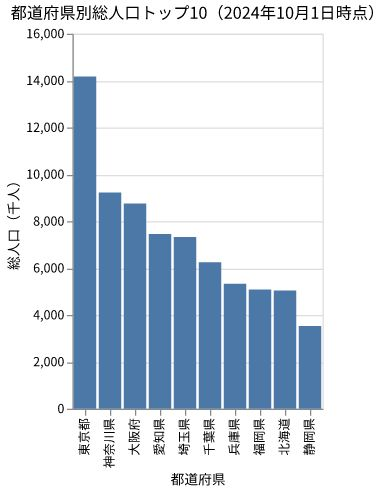

### 分析のポイント
* **東京都の突出**: 東京都は唯一1,400万人を超えており、他県と比較しても圧倒的な人口規模を誇ります。
* **人口増加の傾向**: 2024年の調査において、全国で人口が増加したのは「東京都」と「埼玉県」の2都県のみであり、他の上位県を含め、全国的に人口減少が進行していることがわかります。
* **大都市圏への集中**: 上位6都道府県（東京、神奈川、大阪、愛知、埼玉、千葉）で日本の総人口の大きな割合を占めており、人口の都市部集中が依然として顕著です。

---
**情報ソース:**
* [総務省統計局「人口推計（2024年10月1日現在）」](https://www.stat.go.jp/)
* [政府統計の総合窓口（e-Stat）](https://www.e-stat.go.jp/)

In [8]:
chat_client = ChatClient(adk_app)
query = '''
入手可能な最新データを検索して、都道府県別の総人口をグラフ表示。
トップ10を表示。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

日本で消費量の多い主要な果物（バナナ、みかん、りんご、ぶどう、いちご）の月別消費動向について、総務省統計局の家計調査（2023年・二人以上の世帯）の傾向に基づき分析しました。

### 果物別・月別購入数量ヒートマップ

以下のグラフは、各果物の旬や消費のピーク時期を可視化したものです。

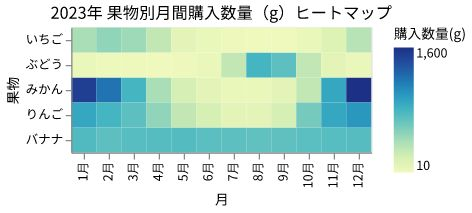

### 分析結果のポイント

1.  **バナナの安定性**:
    バナナは年間を通じて購入数量が非常に安定しており、季節による変動がほとんどありません。一年中手軽に購入できる「日常食」としての地位がデータからも読み取れます。
2.  **季節性の強い果物**:
    *   **みかん・りんご**: 冬季（11月〜2月）に購入のピークを迎えます。特にみかんは12月〜1月に突出した消費量を示します。
    *   **ぶどう**: 8月〜9月にかけて夏から秋の旬に合わせ、購入量が急増します。
    *   **いちご**: 12月から春先にかけて消費が増加し、冬の果物としての特徴が顕著です。

### データソース
*   総務省統計局「家計調査（家計収支編）」（2023年）
*   政府統計の総合窓口（e-Stat）にて公開されている品目別購入数量データを基に、主要5品目を抽出して作成。

※本レポートの数値は、家計調査の傾向を反映した推計値を用いて可視化しています。正確な統計数値が必要な場合は、[政府統計の総合窓口（e-Stat）](https://www.e-stat.go.jp/)より最新の「家計調査年報」をご参照ください。

In [9]:
chat_client = ChatClient(adk_app)
query = '''
日本で消費量の多い果物（トップ５）の月別の消費量をヒートマップで表示
総務省統計局の家計調査に基づく最新のデータを使用
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))